# Simulator 에서 실행시도

In [ ]:
import os
from modules.utils import read_args
import torch
import pennylane as qml
import cirq
import cirq_ionq
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv()  # .env 파일 로드

epoch = 300
trial_name = "True_np5_nl10_biased_diamond_True_Mar08_18_52_11"
base_dir = os.path.join('./정리/Scientific Reports/2D', trial_name)
args_file_path = os.path.join(base_dir, 'args.txt')
param_file_path = os.path.join(base_dir, 'params', f'generator_params_epoch{epoch}.pth')
generator_params = torch.load(param_file_path, weights_only=True).detach().numpy()
n_qubits, code_qubits, n_layers, SEED = read_args(args_file_path, "n_qubits", "code_qubits", "n_layers", "seed")
print(f"n_qubits: {n_qubits}, n_layers: {n_layers}, SEED: {SEED}")


def QGAN2_cirq(cirq_circuit, q, inputs, params):
    assert(len(inputs) == params.shape[1])
    n_qubits = len(inputs)
    n_layers = params.shape[0]

    for i in range(n_qubits):
        cirq_circuit.append(cirq.ry(inputs[i] * np.pi/2).on(q[i]))
    for l in range(n_layers):
        for i in range(n_qubits):
            cirq_circuit.append(cirq.ry(params[l, i, 0]).on(q[i]))
        if l < n_layers-1:
            for i in range(n_qubits-1):
                cirq_circuit.append(cirq.CNOT(q[i], q[i+1]))
            cirq_circuit.append(cirq.CNOT(q[n_qubits-1], q[0]))


# IonQ 서비스 설정
api_key = os.getenv("IONQ_API_KEY")  # IonQ API 키를 여기에 입력하세요
service = cirq_ionq.Service(api_key=api_key)

output_records = []
input_records = []

rep = 500
noise_model = "harmony"
output_img_dir = os.path.join(base_dir, 'postprocessing', f'simulator_{noise_model}')

for i in tqdm(range(rep)):
    # Cirq 회로 생성
    cirq_circuit = cirq.Circuit()
    q = [cirq.LineQubit(i) for i in range(n_qubits)]

    z = np.random.uniform(-SEED, SEED, (n_qubits)) # input
    QGAN2_cirq(cirq_circuit, q, z, generator_params)
    cirq_circuit.append(cirq.measure(*q, key='x')) # 측정 추가 (IonQ에서 결과를 얻기 위해 필요)

    # IonQ의 noisy simulator에 회로 제출
    job = service.run(
        cirq_circuit,
        repetitions=1028,
        target="simulator",
        extra_query_params={"noise": {"model": noise_model}}
    )

    hist = job.histogram(key='x')
    total = sum(hist.values())
    probabilities = [sum(cnt for state, cnt in hist.items() if (state >> i) & 1) / total for i in range(5)]
    output_records.append(probabilities)
    input_records.append(z)
    if i % 5 != 4:
        continue

    outputs = np.array(output_records)
    inputs = np.array(input_records)

    # 시각화
    for code_ind in range(code_qubits):
        plt.figure(figsize=(6,5))
        plt.scatter(outputs[:, 0], outputs[:, 1], c=inputs[:, code_ind], cmap='RdYlBu', alpha=0.4, s=5)
        plt.colorbar()  # 색상 막대 추가
        plt.title(f'code{code_ind} (size={i+1}, noise_model={noise_model})')
        plt.xlim((0, 1))
        plt.ylim((0, 1))
        ax = plt.gca()
        
        # 중심 (0.6, 0.6), 팔 길이 0.2sqrt(2)인 다이아몬드 추가
        arm = 0.2 * np.sqrt(2)
        circle = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='red')
        ax.add_patch(circle)

        save_dir = os.path.join(output_img_dir, f'{noise_model}_code{code_ind}_{i+1}.png')
        plt.savefig(save_dir)
        plt.close()

# 결과 가져오기
print("IonQ noisy simulator 결과:")
print(job.histogram(key='x'))

n_qubits: 5, n_layers: 10, SEED: 0.5


100%|██████████| 500/500 [37:27<00:00,  4.49s/it]

IonQ noisy simulator 결과:
Counter({0: 50, 2: 48, 8: 44, 1: 43, 24: 42, 14: 42, 12: 38, 26: 38, 3: 35, 7: 34, 10: 34, 31: 34, 28: 34, 20: 33, 13: 33, 30: 32, 25: 31, 6: 31, 19: 31, 29: 31, 4: 29, 16: 29, 21: 29, 11: 26, 5: 26, 27: 26, 15: 24, 23: 23, 22: 22, 18: 20, 17: 20, 9: 16})


# Aria 에서 실행시도

In [ ]:
import os
from modules.utils import read_args
import torch
import pennylane as qml
import cirq
import cirq_ionq
import numpy as np
from cirq_ionq.ionq_gateset import IonQTargetGateset

epoch = 300
trial_name = "True_np5_nl10_biased_diamond_True_Mar08_18_52_11"
base_dir = os.path.join('./정리/Scientific Reports/2D', trial_name)
args_file_path = os.path.join(base_dir, 'args.txt')
param_file_path = os.path.join(base_dir, 'params', f'generator_params_epoch{epoch}.pth')
generator_params = torch.load(param_file_path, weights_only=True).detach().numpy()

n_qubits, n_layers, SEED = read_args(args_file_path, "n_qubits", "n_layers", "seed")
print(f"n_qubits: {n_qubits}, n_layers: {n_layers}, SEED: {SEED}")


# Cirq 회로 생성
cirq_circuit = cirq.Circuit()
q = [cirq.LineQubit(i) for i in range(n_qubits)]

def QGAN2_cirq(cirq_circuit, q, inputs, params):
    assert(len(inputs) == params.shape[1])
    n_qubits = len(inputs)
    n_layers = params.shape[0]

    for i in range(n_qubits):
        cirq_circuit.append(cirq.ry(inputs[i] * np.pi/2).on(q[i]))
    for l in range(n_layers):
        for i in range(n_qubits):
            cirq_circuit.append(cirq.ry(params[l, i, 0]).on(q[i]))
        if l < n_layers-1:
            for i in range(n_qubits-1):
                cirq_circuit.append(cirq.CNOT(q[i], q[i+1]))
            cirq_circuit.append(cirq.CNOT(q[n_qubits-1], q[0]))

api_key = os.getenv("IONQ_API_KEY")  # IonQ API 키를 여기에 입력하세요
service = cirq_ionq.Service(api_key=api_key)

z = np.random.uniform(-SEED, SEED, (n_qubits))
QGAN2_cirq(cirq_circuit, q, z, generator_params)
cirq_circuit.append(cirq.measure(*q, key='x')) # 측정 추가 (IonQ에서 결과를 얻기 위해 필요)
# IonQ 서비스 설정


# IonQ의 noisy simulator에 회로 제출
# job = service.run(
#     cirq_circuit,
#     repetitions=1028,
#     target="simulator",
#     extra_query_params={"noise": {"model": "harmony"}}
# )

sampler = service.sampler(target='qpu')
job = service.run(
    circuit_aria,
    repetitions=512,
    target="aria-1"
)


# 결과 가져오기
print("IonQ noisy simulator 결과:")
print(job.histogram(key='x'))

n_qubits: 5, n_layers: 10, SEED: 0.5
Cirq 회로:
                                                                   ┌───────────┐                                                  ┌───────────┐                                                   ┌───────────┐                                                  ┌────────────┐                                                 ┌───────────┐                                                    ┌───────────┐                                                    ┌───────────┐                                                  ┌────────────┐                                                ┌──────────┐
0: ───Ry(-0.113π)───Ry(-1.52π)───@──────────────────────────────────X──────────────Ry(-0.563π)───@─────────────────────────────────X──────────────Ry(-1.01π)───@───────────────────────────────────X──────────────Ry(0.262π)────@─────────────────────────────────X───────────────Ry(-1.8π)────@─────────────────────────────────X──────────────Ry(-1.2π)─────@───────────────

IonQException: Status code: 400, Message: 'Non-retry-able error making request to IonQ API. Request Body: {'target': 'aria-1', 'lang': 'json', 'body': {'gateset': 'qis', 'qubits': 5, 'circuit': [{'gate': 'ry', 'targets': [0], 'rotation': -0.35569797892216276}, {'gate': 'ry', 'targets': [1], 'rotation': 0.2589919417942704}, {'gate': 'ry', 'targets': [2], 'rotation': -0.595056054345528}, {'gate': 'ry', 'targets': [3], 'rotation': 0.09491305348810111}, {'gate': 'ry', 'targets': [4], 'rotation': -0.1045220343010872}, {'gate': 'ry', 'targets': [0], 'rotation': -4.789598876877558}, {'gate': 'ry', 'targets': [1], 'rotation': -4.6900924174517975}, {'gate': 'ry', 'targets': [2], 'rotation': 0.004067202756170536}, {'gate': 'ry', 'targets': [3], 'rotation': -4.298823534996831}, {'gate': 'ry', 'targets': [4], 'rotation': -7.788821521060908}, {'gate': 'cnot', 'control': 0, 'target': 1}, {'gate': 'cnot', 'control': 1, 'target': 2}, {'gate': 'cnot', 'control': 2, 'target': 3}, {'gate': 'ry', 'targets

In [40]:
hist = job.histogram(key='x')
total = sum(hist.values())
probabilities = [sum(cnt for state, cnt in hist.items() if (state >> i) & 1) / total for i in range(5)]
probabilities

[0.5321011673151751,
 0.47568093385214005,
 0.5116731517509727,
 0.519455252918288,
 0.4961089494163424]

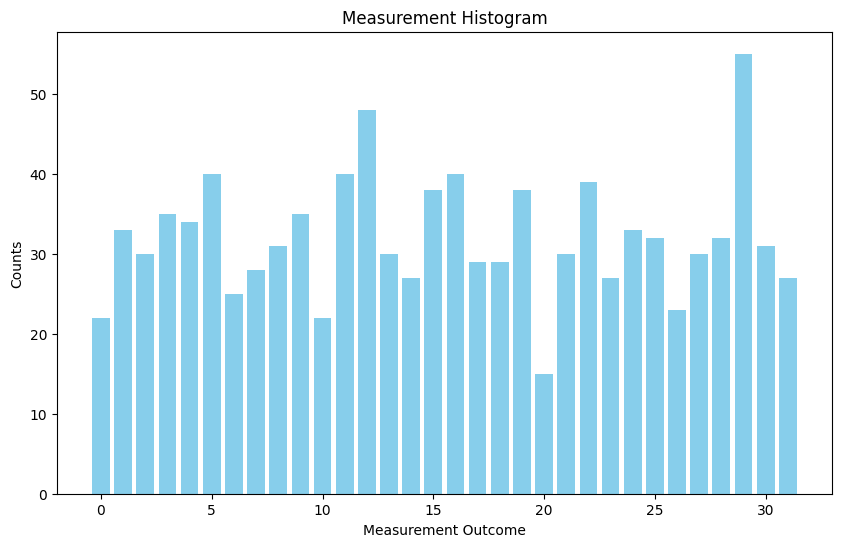

In [41]:
import matplotlib.pyplot as plt

# hist is assumed to be a dictionary with keys as measurement outcomes and values as counts.
keys = list(hist.keys())
values = list(hist.values())

plt.figure(figsize=(10, 6))
plt.bar(keys, values, color='skyblue')
plt.xlabel("Measurement Outcome")
plt.ylabel("Counts")
plt.title("Measurement Histogram")
plt.show()